# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Exploring and Preparing Data


In this notebook, I predicted if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this notebook, I performed Exploratory Data Analysis and Feature Engineering.


Illustration of Falcon 9 first stage landing successfully

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Here are several examples of unsuccessful landings:

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


However, most unsuccessful landings are planned, and Space X performs a controlled landing in the oceans.


## Objectives

Performed exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data Feature Engineering


<div class="alert alert-block alert-info" style="margin-top: 20px">

<h2>Table of Contents</h2>

***
   
- [Importing Libraries and Defining Functions](#importing)
- [Exploratory Data Analysis](#data)
- [Feature Engineering](#feature)
- [Author](#author)
    
<p>

</div>

<hr>

### Importing Libraries and Defining Functions
<a id="importing"></a>

Importing the necessary libraries


In [1]:
import warnings
warnings.filterwarnings('ignore')
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis
<a id="data"></a>

First, reading the SpaceX dataset into a Pandas dataframe and printing its summary


In [2]:
df=pd.read_csv("dataset_part_2.csv")
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, analyzing how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

I ploted out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. It can be noticed that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.


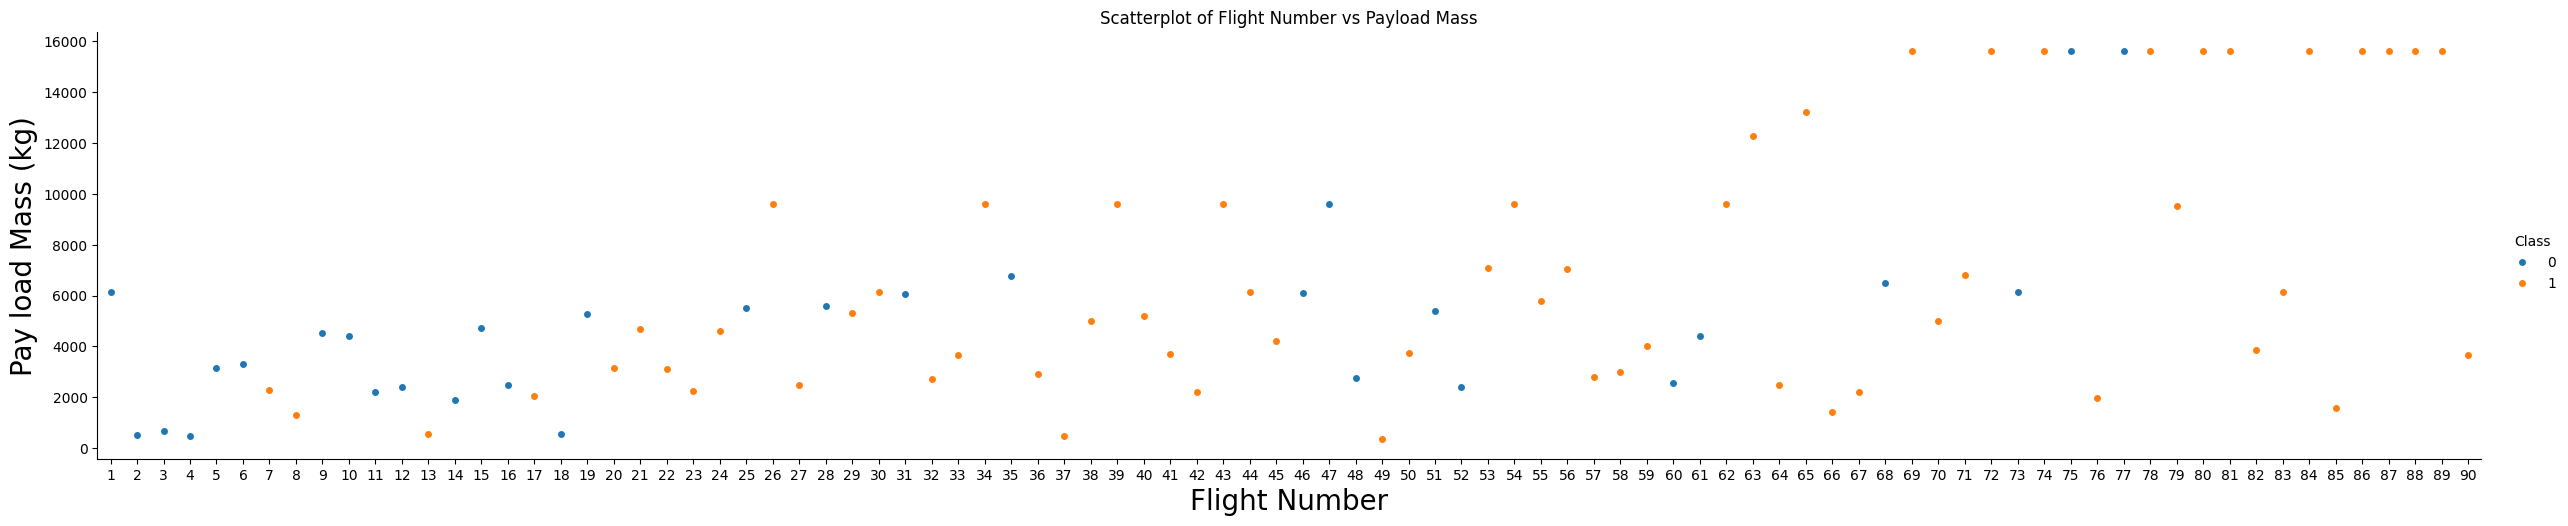

In [8]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.title("Scatterplot of Flight Number vs Payload Mass")
plt.show()

Next, analyzing each site to visualize its detailed launch records.


### Visualizing the relationship between Flight Number and Launch Site
<a id="visualize"></a>

Using the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>. Setting the  parameter <code>x</code> to parameter <code>FlightNumber</code>, <code>y</code> to <code>Launch Site</code> and the parameter <code>hue</code> to <code>'class'</code>


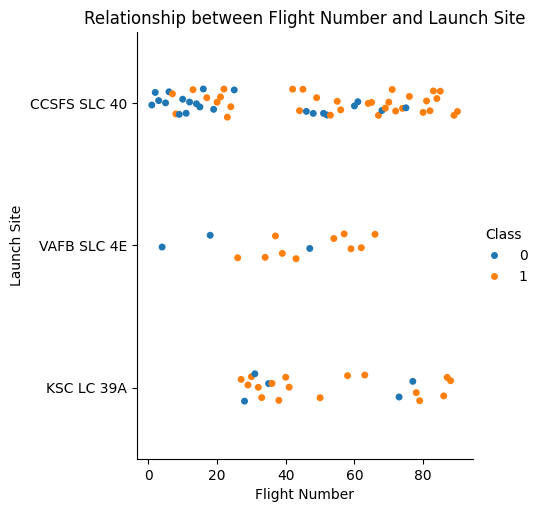

In [7]:
# Ploting a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
sns.catplot(x= df["FlightNumber"], y= df["LaunchSite"], hue= df["Class"])
plt.xlabel("Flight Number")
plt.ylabel("Launch Site")
plt.title("Relationship between Flight Number and Launch Site")
plt.show()

### Analysis:
- Most of the earliest flights failed while the latest flights all succeeded.

- The CCSFS SLC 40 launch site consist of a half of total launches and a higher chance of failure when the flight number was low.

- VAFB SLC 4E and KSC LC 39A have higher success rates compared to CCSFS SLC 40.

- It can be assumed that each new launch has a higher rate of success.

### Visualizing the relationship between Payload Mass and Launch Site
<a id="vis"></a>

Trying to observe if there is any relationship between launch sites and their payload mass.


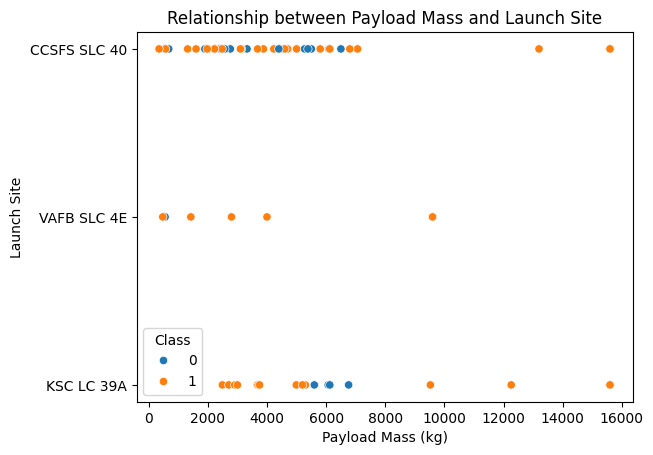

In [9]:
# Ploting a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
sns.scatterplot(x= df["PayloadMass"], y= df["LaunchSite"], hue= df["Class"])
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Launch Site")
plt.title("Relationship between Payload Mass and Launch Site")
plt.show()

Observing Payload Mass Vs. Launch Site scatter point chart, I was able to find that for the <code>VAFB SLC 4E</code> launchsite there are no  rockets  launched for  heavy payload mass (greater than 10000 kg).


### Visualizing the relationship between success rate of each orbit type
<a id="vis2"></a>

Next, visually checking if there are any relationship between success rate and orbit type by creating a `bar chart`


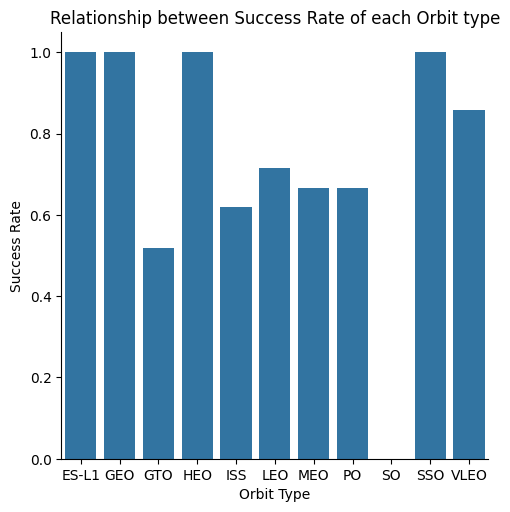

In [10]:
# using groupby method on Orbit column and getting the mean of Class column
sns.catplot(x= 'Orbit', y = 'Class', data = df.groupby('Orbit')['Class'].mean().reset_index(), kind = 'bar')
plt.xlabel('Orbit Type')
plt.ylabel('Success Rate')
plt.title("Relationship between Success Rate of each Orbit type")
plt.show()

### Analysis:

- ES-L1, GEO, HEO, and SSO orbits have 100% success rates.

- SO orbit has 0% success rate

- Other orbits including GTO, ISS, LEO, MEO, and PO have success rate between 50% to 85%

### Visualizing the relationship between FlightNumber and Orbit type


For each orbit, checking if there is any relationship between FlightNumber and Orbit type.


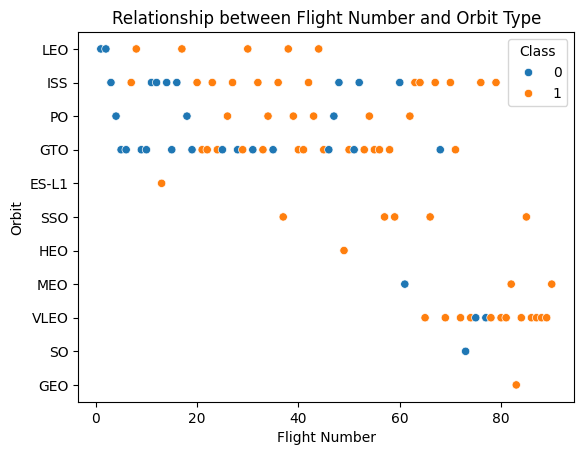

In [11]:
# Ploting a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
sns.scatterplot(x=df["FlightNumber"], y=df["Orbit"], hue= df["Class"])
plt.xlabel("Flight Number")
plt.ylabel("Orbit")
plt.title("Relationship between Flight Number and Orbit Type")
plt.show()

### Analysis:
- I can observe that in the LEO orbit, success seems to be related to the number of flights. 
- Contrastingly, in the GTO orbit, there appears to be no relationship between flight number and success. 
- SSO, HEO, GEO and ES-L1 orbit have 100% succeess rate but all of these orbits have less sample to get a concrete conclusion.
- VLEO orbit seems to have a consistently higher success rate as flight number increases.


### Visualizing the relationship between Payload Mass and Orbit type


Similarly, I ploted the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type


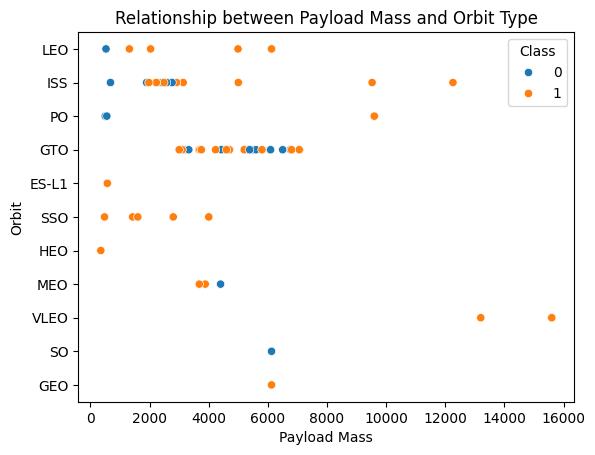

In [12]:
# Plot a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class value
sns.scatterplot(x=df["PayloadMass"], y=df["Orbit"], hue= df["Class"])
plt.xlabel("Payload Mass")
plt.ylabel("Orbit")
plt.title("Relationship between Payload Mass and Orbit Type")
plt.show()

### Analysis:

- With heavy payloads, the successful landing rate are more for PO, LEO, and ISS.

- However, for GTO, it's difficult to distinguish between successful and unsuccessful landings as both outcomes are present.


### Visualizing the launch success yearly trend


Ploting a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend.


In [13]:
# Using a function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


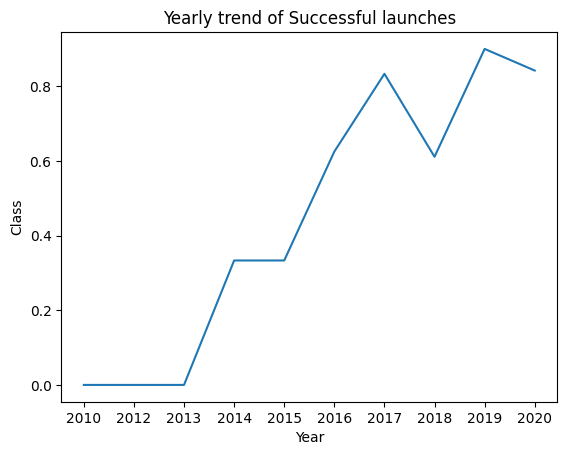

In [15]:
# Ploting a line chart with x axis to be the extracted year and y axis to be the success rate
sns.lineplot(x="Date", y="Class", data= df.groupby("Date")["Class"].mean().reset_index())
plt.xlabel("Year")
plt.ylabel("Class")
plt.title("Yearly trend of Successful launches")
plt.show()

### Analysis:

- I can observe that the sucess rate since 2013 kept increasing till 2020
- However, a significant decrease is seen from year 2017 to 2018 which was due to more difficult missions, intentional expendable launches, and transitioning to upgraded hardware with a few techincal failure.
- Period of 2014 to 2015 was the R&D phase. Hence, the success rate is flat.


## Feature Engineering
<a id="feature"></a>

By now, I have obtained some preliminary insights about how each important variable would affect the success rate. I have selected the features that will be used in success prediction.


In [16]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6123.547647,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCSFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### Creating dummy variables to categorical columns


Using the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Then, assigned those values to the variable <code>features_one_hot</code>


In [17]:
# Using get_dummies() function on the categorical columns
features_one_hot= pd.get_dummies(features[["Orbit", "LaunchSite", "LandingPad", "Serial"]])
features_one_hot.head()

,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Casting all numeric columns to `float64`


Now that the <code>features_one_hot</code> dataframe only contains numbers, I casted the entire dataframe to  the <code>float64</code> variable type


In [19]:
# Using astype function
features_one_hot.astype("float64")

,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Now, exporting it to a <code>CSV</code> file.


In [22]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)

## Author
<a id="author"></a>

- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b)


<!--## Change Log-->


<!--
| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|
| 2024-07-18        | 1.2     | Anita Verma | Clarified instructions|
-->
